# Who Matters

This week mostly covers questions like "who matters" in the sense of "who can we remove" if we want to split the graph. We also are going to cover:

- __Degree Centrality__ (P): how many direct connections do we have?
- __Closeness Centrality__ (P): how quickly can we reach everyone?
- __Betweeness Centrality__ (P): how often are you the _bridge_ between others?
- __Eigenvector Centrality / PageRank__ (RW): are you connected to _important_ other nodes?

The first three are based on _paths (P)_, whereas the last one is based on _random walks (RW)_.

## Paths, Distances & Components
- __Walk__: any _sequence_ of nodes where each consecutive pair is linked.
    - With the _adjacency matrix_, we can find the number of _walks_ of length $n$ between nodes $i$ and $j$ with $A^n$ if entry $A_{ij}^n > 0$. We can find walks of length $n$ _or shorter_ if we do $(A + I)^n$, where $I$ is the identity matrix representing self-loops. Otherwise, the diagonal of $A^n$ is how many loops we can find of length $n$.
    - Interrestingly, degree can be found with $A_{u,u}^2 = d_{u}$!
    - If two nodes _can't_ connect by a walk of any length, then they are in different _components_!
- __Path__: a _walk_ that contain _no repeated nodes_!
    - Dijkstras allows you to find _shortest paths_ in weighted versions.
    - Floyd-Warshall finds all pairs of _shortest paths_ if not considering single origin and/or destination.
    - _Path Distribution_: quasi-normal, usually bell-shaped.
- __Distance__ $d_{uv}$: the _shortest_ path between two nodes, if not path then $d_{uv} = \infty$.
    - Also the largest value the _path distribution_ takes (left-most column)
- __Average Path Length__ $\langle d\rangle$: over _all_ pairs in the _giant component_.
    - $\langle d\rangle = \frac{\sum_{u,v\in V}|d_{uv}|}{|V|(|V|-1)}$
    - $\langle d_u\rangle  = \frac{\sum_{v\in V}|d_{uv}|}{|V|(|V|-1)}$
- __Diameter__: the _longest_ of the _shortest_ paths; grows like _small-world_ fact so $\log n$.
    - The _worst case_ reachability in the network;
    - Network with two seperate components have a diameter of $\infty$.
- __eccentricity__: the diameter with respect to a node, so the distance to the farthest node!

Try to cultivate two habits for every centrality number you ever report:
- __Say which question__. Degree for popularity, closeness for reach, betweenness for control, PageRank for prestige. On the Marvel network the four top-ten lists overlap on six to eight names, and the rank correlation between degree and betweenness is 0.910.91, so most of the time they agree, and the disagreements are the interesting part.
- __Say compared to what__. This one is more general. It really is something you should try to do for any measure. You can only really understand if a centrality high or low if you compare it to a null model. The degree-preserving shuffle is the right one for the "is this node's position more than its degree?" question.

To calculate paths easily we will use __Breadth-First Search (BFS)__. It is very simple
1. Select a node, everything it links to is _distance 1_!
2. Everything the neighbours link to is then _distance 2_!
3. Repeat until all nodes have been visited.

If you run it for all nodes, then you get all the things we want to calculate like distances, average distance and diameter. If you run BFS on _unweighted_ graphs, you find _shortest paths_ as well!

We can also have __weakly__ or __strongly__ connected components:
- __Strongly Connected__: all nodes can reach each other by _following arrows_! Everyone can go to everyone else in the component.
- __Weakly Connected__: all nodes can be reached if you follow edges undirected.

The number of eigenvalues of the adjacency matrix $A$ that are equal to 1, gives you the number of components in the network! Each adjacency matrix has a maximum eigenvalue of $1$ and since two components are disjoint, they each have a maximum eigenvalue of 1. The eigenvectors to those eigenvalues will have 0's in the places of the nodes for the other components.


### 3.1 paths
1) Walk vs path vs shortest path: define all three, then give an example of a walk of length 4 in a triangle that is not a path:
    - Walk: any sequence of nodes connected by edges, repeats allowed;
    - Path: A sequence of nodes following edges, no repeat nodes allowed;
    - Shortest path: the minimum length of all paths for a node.
    - A walk if we have triangle ABC is $[A,B,A,B]$
2) Explain BFS to someone who has never seen it, in five sentences or fewer, and say why the ring a node lands in is guaranteed to be its shortest distance from the start.
    - Think of BFS as a way to colour a person depending on how far from you they are. Say all friends you can reach you color "green", then you tell them; "Hey, go colour your uncolored friends a new color!" (assuming they choose the same color). They will have maybe red. This continues. Because you colored all you could reach green first, they are your closest friends, the red ones will be the next-closest by definition! This repeats.
3) In a directed network, $d_{AB}​=2$ and $d_{BA}=\infty$. Draw the smallest network in which that is true. What do "weakly connected" and "strongly connected" mean, and which of them does your drawing have?
    - $A -> C -> B$
    - Weakly means we can reach others regardless of direction; strongly means all nodes in the component can reach the others following the arrows. My example is a _weakly_ connected one.
4) The Marvel network has $\langle d\rangle=2.67$. The random network with the same $n$ and $m$ (your table from week 2) has $\langle d\rangle=2.8$. Is the real network's value evidence of anything? What would be?
    - I would not say it is evidence of anything for the real network, more so that the random network is is evidence that it may follow the real worlds average distances. 

### 3.2 BFS by hand

![image.png](image.png)

1. Run BFS from node 1. Write the nodes ring by ring (distance 0, 1, 2, …). What is the eccentricity of node 1 (its distance to the farthest node)?
    - Distance 0: $[1]$; Distance 1: $[2, 3]$, Distance 2: $[4]$; Distance 3: $[5]$; Distance 4: $[6, 7]$; Distance 5: $[8]$; distance to farthest node: 5!
2. Run BFS from node 5. Which nodes are the network's center (smallest eccentricity), and what is the diameter?
    - Distance 0: $[5]$; Distance 1: $[4, 6, 7]$, Distance 2: $[2, 3, 8]$; Distance 3: $[1]$; diameter is 3, and the _center_ of the network is node $4$ and $5$, because they have the smallest _eccentricity_.
3. Now make the links 4→5 and 5→6 directed (all others stay undirected). Recompute the distances from node 1 and from node 6. Which pairs became unreachable?
    - Node 1: this will give the same distances.
    - Node 6: is isolated now!
4. Count the shortest paths from 1 to 5. (There are two.) You will need this way of counting in Section 4.
    - First: $[1, 2, 4, 5]$
    - Second: $[1, 3, 4, 5]$


<d>: 2.67, Diameter: 6, Radius: 3, Center: ['Spider-Man']


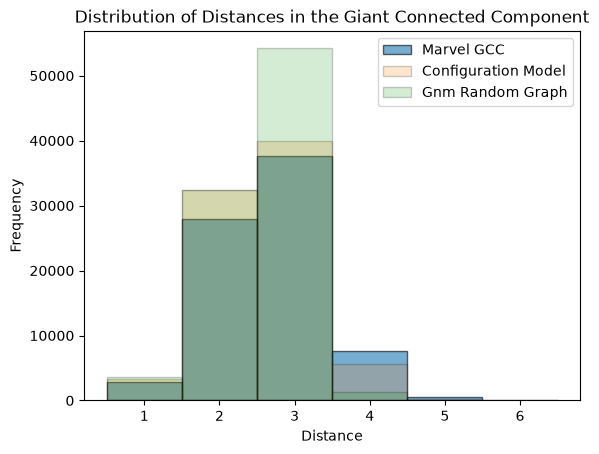

As we see, the configuration model preserves the same distance distribution much more than the random null model does. This tells us that the degree distribution is a key factor in determining the distance distribution of a network.
GCC Nodes: 229, Edges: 1636
Fraction of reachable ordered pairs: 0.69
Mean directed distance: 3.43
Found pair: A=Ajak, B=Makkari_(character) | d_AB=1, d_BA=5


In [24]:
# 3.3
import random
from collections import deque

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

nodes = pd.read_csv("../Week1/week1_nodes.tsv", sep="\t", comment="#",
                    quoting=3)  # QUOTE_NONE: TSVs never quote, but blurbs may contain "quotes"
edges = pd.read_csv("../Week1/week1_edges.tsv", sep="\t", comment="#",
                    names=["source", "target"])

G = nx.DiGraph()
G.add_nodes_from(nodes.node_id)
G.add_edges_from(edges.itertuples(index=False))
# G: 303 nodes, 1784 edges
# Extracting the giant connected component
component_nodes = max(nx.connected_components(G.copy().to_undirected()), key=len)
largest_component = G.subgraph(component_nodes).to_undirected().copy()

# Average distance, diameter, radius and center of the component:
avg_distance = nx.average_shortest_path_length(largest_component)
diameter = nx.diameter(largest_component)
radius = nx.radius(largest_component)
center = nx.center(largest_component)

print(f"<d>: {avg_distance:.2f}, Diameter: {diameter}, Radius: {radius}, Center: {center}")

# Random Network & Configuration Model
configuration_multigraph = nx.configuration_model([degree for _, degree in G.degree()], seed=123)
configuration_graph = nx.Graph(configuration_multigraph)
configuration_graph.remove_edges_from(nx.selfloop_edges(configuration_graph))
gnm_graph = nx.gnm_random_graph(G.number_of_nodes(), G.number_of_edges(), seed=123)

# Plot distribution of distances
all_distances_G = [
    dist
    for source, targets in nx.all_pairs_shortest_path_length(largest_component)
    for target, dist in targets.items()
    if source != target
]

all_distances_configuration = [
    dist
    for source, targets in nx.all_pairs_shortest_path_length(configuration_graph)
    for target, dist in targets.items()
    if source != target
]

all_distances_gnm = [
    dist
    for source, targets in nx.all_pairs_shortest_path_length(gnm_graph)
    for target, dist in targets.items()
    if source != target
]

# Use max(all_distances) + 2 so the range includes the upper bound
plt.hist(
    all_distances_G,
    bins=range(min(all_distances_G), max(all_distances_G) + 2),
    edgecolor="black",
    align="left",
    alpha=0.6,
    label="Marvel GCC",
)
plt.hist(
    all_distances_configuration,
    bins=range(min(all_distances_configuration), max(all_distances_configuration) + 2),
    edgecolor="black",
    align="left",
    alpha=0.2,
    label="Configuration Model",
)
plt.hist(
    all_distances_gnm,
    bins=range(min(all_distances_gnm), max(all_distances_gnm) + 2),
    edgecolor="black",
    align="left",
    alpha=0.2,
    label="Gnm Random Graph",
)
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title("Distribution of Distances in the Giant Connected Component")
plt.legend()

# REMOVE THIS TO SHOW THE DISTRIBUTION EARLIER IN THE OUTPUT
plt.show()

print("As we see, the configuration model preserves the same distance distribution much more than the random null model does. This tells us that the degree distribution is a key factor in determining the distance distribution of a network.")

# We now try and keep the directed arrows, and find the largest connected component.
GCC_ = max(nx.strongly_connected_components(G), key=len)
GCC = G.subgraph(GCC_).copy()
print(f"GCC Nodes: {GCC.number_of_nodes()}, Edges: {GCC.number_of_edges()}")

all_paths = dict(nx.all_pairs_shortest_path_length(G))
N = G.number_of_nodes()
total_ordered_pairs = N * (N - 1)

reachable_distances = [
    dist
    for u, targets in all_paths.items()
    for v, dist in targets.items()
    if u != v
]

fraction_reachable = len(reachable_distances) / total_ordered_pairs
mean_directed_distance = np.mean(reachable_distances)

print(f"Fraction of reachable ordered pairs: {fraction_reachable:.2f}")
print(f"Mean directed distance: {mean_directed_distance:.2f}")

matching_pair = None
for A in G.nodes():
    for B in G.successors(A):  # d_AB == 1
        d_BA = all_paths.get(B, {}).get(A, float("inf"))
        if d_BA >= 5:
            matching_pair = (A, B, 1, d_BA)
            break
    if matching_pair:
        break

if matching_pair:
    print(f"Found pair: A={matching_pair[0]}, B={matching_pair[1]} | d_AB={matching_pair[2]}, d_BA={matching_pair[3]}")
else:
    print("No such pair found.")

def manual_bfs(graph: nx.Graph, start_node):
    if start_node not in graph:
        raise ValueError(f"Start node {start_node} not in graph.")

    visited = {start_node}
    queue = deque([start_node])
    traversal_order = []

    while queue:
        current = queue.popleft()
        traversal_order.append(current)

        for neighbor in graph.neighbors(current):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

    return traversal_order

def assert_bfs_matches_networkx(graph: nx.Graph, num_nodes: int = 20):
    sample_nodes = random.sample(list(graph.nodes()), min(num_nodes, graph.number_of_nodes()))
    
    for node in sample_nodes:
        custom_result = manual_bfs(graph, node)
        nx_result = list(nx.bfs_tree(graph, source=node).nodes())
        assert custom_result == nx_result, f"Mismatch for start node {node}"

assert_bfs_matches_networkx(G, num_nodes=20)


## Degree & Closeness

- __Degree Centrality__: $k_i$ or for directed it is $k_{i}^{out}$ and $k_{i}^{in}$. It is _local_, cheap and often right.
- __Closeness Centrality__: mean distance from node $i$ to all other nodes, then the inverse (so closeness to others give large values) $$ C_i^{close} = \frac{N - 1}{\sum_{j\neq i} d_{ij}}, $$ so a node with closeness $0.5$ is two steps from everybody on average. If _any_ node is unreachable, we get $C_i^{close} = 0$, so the measure breaks often in directed networks or networks with components. A standard fix is the __harmonic centrality__: $$ C_i^{harm} = \frac{1}{n - 1}\sum_{j\neq i}\frac{1}{d_{ij}}. $$ Now unreachable nodes contribute 0 instead.

## Betweenness: the _broker_

__Betweenness centrality__: for every pair of other nodes $s,t$, count the fraction of their shortest paths that pass through $i$ and add it up:

$$b_i = \sum_{s\neq i\neq t} \frac{\sigma_{st}(i)}{\sigma_{st}},$$
where $\sigma_{st}$ is the number of shortests paths from $s$ to $t$, and $\sigma_{st}(i)$ are those that go through $i$ - neither as origin nor destination. If we divide by the number of pairs $(n-1)(n-2)/2$, we get for an undirected network a number between 0 and 1.

This is a measure of a _bridge_, _broker_, if removed it breaks flow; it is a measure of _control_! But it __is not__ a measure of degree.

### 3.4
(From the webpage, at 3.4, is a figure. it is based on that)
1. Compute the closeness of nodes D, F, and J from their distance lists. Explain in one sentence why F beats D even though D has more links.
    - D: $9/(6\cdot 1 + 2 + 3 + 4) = 9/15 = 0.6 $
    - F: $9/(5\cdot 1 + 3\cdot 2 + 3) = 9/14 \approx 0.64$
    - J: $9/(1 + 2 + 2\cdot 3 + 5\cdot 4) = 9/29 \approx 0.31 $
    - F beats D because F has a lower average distance to everyone else, far out nodes weight a lot, and since D is one step further from J, it takes a toll.
2. Compute the betweenness of H. _Hint:_ H sits on every shortest path between {I, J} and the other seven nodes, and on no others. How many such pairs are there? Now do I, and explain why I has substantial betweenness with only two links.
    - H: counting paths from $I$ to anything above $H$: 1 unique going to F and G, sum 2. Then 2 different lengths going to D, sum 4; 1 unique going to C,A,B,E, 2 of those are through F, others through G, so sum is 8. We double up, as similar paths from $J$. So in total, we have 16 paths going _through_ $i$! $I$ and $H$ has substantial betweenness, despite lower degree, for exactly this reason; all paths that want to talk to for example J, has to go through them; similar the other way.
3. Compute the betweenness of C. (It should be zero. Why?)
    - It is 0, because no shortest paths actually go through C.
4. In exercise 3.2's network, which node has the highest betweenness? Compute it, using your count of shortest paths from item 4 there.
    - [1, 6, 8]: has betweenness $0$
    - [5]: has betweenness $$
5. 
6. For each of these questions, say which measure you would use and why: whom to vaccinate first · whose retirement would hurt the company most · who has the most friends · which airport's closure delays the most journeys.
    - _whom to vaccinate first_: based on _betweenness_ because vaccinating this person removes that viral flow.
    - _whose retirement would hurt the company most_: based on _betweenness_, as removing these remove information flow! May fragment the network.
    - _who has the most friends_: based on _degree_, as it litterally tells us that!
    - _which airport's closure delays the most journeys_: based on _betweenness_


Shared top 10 nodes across all four centrality measures: {'Turbo_(comics)', 'Digitek_(character)', 'William_Burnside_(character)', 'Dragon_Lord_(character)', 'Gladiator_(Kallark)', 'John_Jameson_(character)', 'Rom_the_Space_Knight', 'Gwenpool', 'Black_Panther_(character)', 'Darkhawk', 'Union_Jack_(Marvel_Comics)', 'Union_Jack_(Joseph_Chapman)', 'Jack_Frost_(Marvel_Comics)', 'Toro_(character)', 'Karnak_(character)', 'Spider-UK', 'Abomination_(character)', 'Wolverine_(Ultimate_Marvel_character)', 'Starhawk_(character)', 'Iron_Fist_(character)', 'Thor_Girl', 'She-Hulk', 'Agent_X_(Marvel_Comics)', 'Nova_(Richard_Rider)', 'Kismet_(Marvel_Comics)', 'Patsy_Walker', 'Scarlet_Witch', 'Rockman_(character)', 'G._W._Bridge', 'Kid_Colt', 'Alex_Wilder', 'Mahr_Vehl', 'Human_Torch_(android)', 'Korvus', 'Box_(comics)', 'Dargo_Ktor', 'Rocket_Raccoon', 'Hit-Monkey', 'Red_Wolf_(comics)', 'Janice_Lincoln', 'Doctor_Druid', 'Vance_Astrovik', 'Firebird_(Marvel_Comics)', 'Wild_Child_(character)', "Will_o'_the_

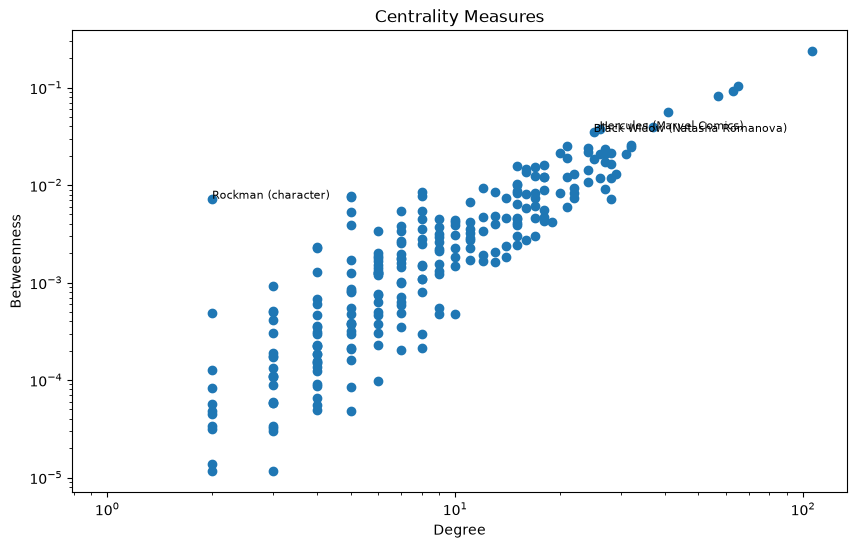

Black Widow Neighbors:
- Ghost Rider (Johnny Blaze)
- Hercules (Marvel Comics)
- Red Guardian
- Spider-Man
- Venom (character)
- Wolverine (character)
- Yelena Belova
Hercules Neighbors:
- Abomination (character)
- Ajak
- Ares (Marvel Comics)
- Balder the Brave
- Black Widow (Natasha Romanova)
- Captain Marvel (Marvel Comics)
- Firelord (character)
- Hulk
- Human Torch
- Living Lightning
- Noh-Varr
- Quicksilver (Marvel Comics)
- Red Guardian
- Red Wolf (comics)
- She-Hulk
- Spider-Man
- Star-Lord
Rockman Second Neighbors:
- Hercules (Marvel Comics)
- Red Guardian
- Spider-Man
- Ghost Rider (Johnny Blaze)
- Wolverine (character)
- Venom (character)
- Yelena Belova


In [17]:
# Degree, Closeness, Harmonic and Betweenness for the _undirected_ giant compoent of Marvel (top 10 each)
degree = largest_component.degree()
degree_names = {val[0] for val in sorted(degree, key=lambda x: x[1], reverse=True)}
all_names = {val[0] for val in sorted(degree, key=lambda x: x[1], reverse=True)}

closeness = nx.closeness_centrality(largest_component)
closeness_names = {val[0] for val in sorted(closeness.items(), key=lambda x: x[1], reverse=True)}

harmonic = nx.harmonic_centrality(largest_component)
harmonic_names = {val[0] for val in sorted(harmonic.items(), key=lambda x: x[1], reverse=True)}

betweenness = nx.betweenness_centrality(largest_component)
betweenness_names = {val[0] for val in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)}

shared = degree_names & closeness_names & harmonic_names & betweenness_names
print(f"Shared top 10 nodes across all four centrality measures: {shared}")

# Scatterplot of betweenness vs degree (log axes)
# Label each point by their character name (no longer top 10)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.loglog([degree[n] for n in all_names], [betweenness[n] for n in all_names], 'o')
plt.labels = {n: nodes[nodes.node_id == n].name.values[0] for n in all_names}
for n, label in plt.labels.items():
    if "Black Widow" in label or "Hercules" in label or "Rockman" in label:
        plt.annotate(label, (degree[n], betweenness[n]), fontsize=8)
plt.xlabel('Degree')
plt.ylabel('Betweenness')
plt.title('Centrality Measures')
plt.show()

# print Black Widow and Hercules neighbours:
print("Black Widow Neighbors:")
black_widow_id = nodes[nodes.name == "Black Widow (Natasha Romanova)"].node_id.values[0]
black_widow_neighbors = list(G.neighbors(black_widow_id))
for neighbor in black_widow_neighbors:
    neighbor_name = nodes[nodes.node_id == neighbor].name.values[0]
    print(f"- {neighbor_name}")

print("Hercules Neighbors:")
hercules_id = nodes[nodes.name == "Hercules (Marvel Comics)"].node_id.values[0]
hercules_neighbors = list(G.neighbors(hercules_id))
for neighbor in hercules_neighbors:
    neighbor_name = nodes[nodes.node_id == neighbor].name.values[0]
    print(f"- {neighbor_name}")

# As they both connect Spider Man, they may be part of paths that connect to other characters,
# explaining their high betweenness centrality.

# Checking Rockman second neighbours:
print("Rockman Second Neighbors:")
rockman_id = nodes[nodes.name == "Rockman (character)"].node_id.values[0]
rockman_second_neighbors = []
for neighbor in G.neighbors(rockman_id):
    second_neighbors = list(G.neighbors(neighbor))
    rockman_second_neighbors.extend(second_neighbors)
rockman_second_neighbors = set(rockman_second_neighbors) - {rockman_id}
for second_neighbor in rockman_second_neighbors:
    second_neighbor_name = nodes[nodes.node_id == second_neighbor].name.values[0]
    print(f"- {second_neighbor_name}")

# It seems Rockman may have a high betweenness centrality because he connects with Spider Man.

## Who has important friends?

Not all links are equally weighted, or important, for that matter. A link from/to SpiderMan in Marvel is worth more than other links, as Spider Man is very connected to many others.

A node is important if it is linked to _by_ important nodes. As a equation,
$$ x_i = \frac{1}{\lambda}\sum_{j}A_{ij}x_j. $$

Every node's score is a sum of its neighbour scores, scaled by $\lambda$. A vector that satisfies this for every node at once is an _eigenvector_ of the adjacency matrix. The eigenvector with only positive entries is the __eigenvector centrality__!

Can be calculated with iterations, start everyone at 1, then replace with scores by above, until convergence.

__PageRank__ is a related measure in _directed_ graphs, based on _random walks_! The idea is to randomly walk the graph, and with small probability $\epsilon = \alpha$, we teleport to a random node; this is to navigate out of dead ends or small loops. Then count how many times we enter a page ( or node).

To the (unnormalized) adjacency matrix we add it:
$$ A^* = A + \epsilon = A + \alpha, $$

where we usuall call $1-\epsilon = 1-\alpha$ the "dampning factor". The probability of following a link is then;
$$ PR_i = \frac{1-\alpha}{n} + \alpha\sum_{j\rightarrow i}\frac{PR_j}{k_j^{out}} $$

### 3.6


1. Start with $PR=0.25$ for every node and $\alpha=0.85$. Apply the PageRank equation once, to all four nodes, and write down the new vector. (D has no incoming links; what does it get, and from where?) Apply it a second time. Which node is winning, and why does A score well with a single incoming link?
    - First Rounds:
        - $PR_A = \frac{1-0.85 = 0.15}{4} + 0.85(0.25) = 0.25$
        - $PR_B = \frac{0.15}{4} + 0.85(0.25/2) = 0.14375$
        - $PR_C = \frac{0.15}{4} + 0.85(0.25/2 + 0.25 + 0.25) = 0.56875$
        - $PR_D = \frac{0.15}{4} + 0.85(0) = 0.0375$
    - First Rounds:
        - $PR_A = \frac{1-0.85 = 0.15}{4} + 0.85(0.56875) = 0.521$
        - $PR_B = \frac{0.15}{4} + 0.85(0.25/2) = 0.14375$
        - $PR_C = \frac{0.15}{4} + 0.85(0.25/2 + 0.14375 + 0.0375) = 0.2978$
        - $PR_D = \frac{0.15}{4} + 0.85(0) = 0.0375$
    - A scores well, because it links to C, which is linked to by many!
2. Set $\alpha = 1$ (no teleporting). What happens to D's score, and after that to the whole thing? Say in one sentence what teleportation is for.
    - First Rounds:
        - $PR_A = 0.25$
        - $PR_B = 0.25/2 = 0.125$
        - $PR_C = 0.25/2 + 0.25 + 0.25 = 0.625$
        - $PR_D = 0$
    - First Rounds:
        - $PR_A = 0.625$
        - $PR_B = 0.25/2 = 0.125$
        - $PR_C = 0.25/2 + 0.125 = 0.25$
        - $PR_D = 0$
    - It "forgets" aboud D, and so fails to count those pages who are not linked to, as part of the reason why a page, in this case C, is important. It makes C seem less important than it might really be. Teleportation is for reaching these otherwise unreachable pages, which on might land in if you knew what random webpage you wanted to go for (writing it directly!)
3. Explain the difference between eigenvector centrality and PageRank in terms of what one node's link is worth when that node has many out-links. Then: in an undirected network, what does the random walker's stationary distribution reduce to?
    - In PageRank, the out-links are worth based on in-degree as well; we saw that in D, the worth of it reduced to 0 immediately after removing teleportation, but it does have an out degree.
    - In an undirected network, the random walker's stationary distribution reduces down to the probability of landing in a node $j$ regardless of which nodes you start in; in mathematical terms, it corresponds to the eigenvector (as rows) corresponding to the Eigenvalue of 1 for the adjacency matrix.

In [18]:
# PageRank on Marvel fully directed graph
pagerank = nx.pagerank(G, alpha=0.85)
pagerank_top10 = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]

# Top 10 on in-degree
degrees_in = G.in_degree()
degrees_in_top10 = sorted(degrees_in, key=lambda x: x[1], reverse=True)[:10]

for (node_id, pr_value), (in_node_id, in_degree) in zip(pagerank_top10, degrees_in_top10):
    # Print node name and page rank, on right the Node name and in-degree
    node_name_pr = nodes[nodes.node_id == node_id].name.values[0]
    node_name_in = nodes[nodes.node_id == in_node_id].name.values[0]
    print(f"Node: {node_name_pr:<40} PageRank: {pr_value:.4f}: {node_name_in:<40} In-Degree: {in_degree}")

Node: Spider-Man                               PageRank: 0.0501: Spider-Man                               In-Degree: 106
Node: Hulk                                     PageRank: 0.0280: Hulk                                     In-Degree: 64
Node: Wolverine (character)                    PageRank: 0.0259: Wolverine (character)                    In-Degree: 60
Node: Doctor Strange                           PageRank: 0.0207: Doctor Strange                           In-Degree: 50
Node: Black Cat (Marvel Comics)                PageRank: 0.0176: Deadpool                                 In-Degree: 33
Node: Deadpool                                 PageRank: 0.0148: She-Hulk                                 In-Degree: 29
Node: Mayday Parker                            PageRank: 0.0143: Scarlet Witch                            In-Degree: 28
Node: Venom (character)                        PageRank: 0.0137: Black Panther (character)                In-Degree: 27
Node: Phoenix (Guardians of the Galaxy)

## Compared to what?

Null-models make a return; remember, a null-model helps us confirm stuff that may believe about the network. That a large degree measures also high betweenness!

Spider-Man as an example has 23% of all shortest paths go through him; if we shuffle the network 200 times, degree-preserving, and recompute: averages out at 23% as well!

However, others go down; hercules from 0.037 to 0.018 (4 standard deviations)!

### 3.8 Brokers, compared to what?
1. Before computing anything: a node has degree 2 and the highest betweenness in its network. Draw a network where this happens. Then draw one where the highest-degree node has betweenness zero.
    - First: assume two components, connected by a single node in the middle; this middle node has degree 2, but the highest betweenness is that 2 degree node.
    - Second: take a triangle; now connect a node to each of these nodes; it will have 3 degree, compared to the 2, but no betweenness.
2. Shuffle-test betweenness on the Marvel giant component: 200 degree-preserving shuffles, and for every character the $z$-score of the real betweenness against the shuffled distribution. Plot $z$ against degree. Which characters are the surprises, in both directions? Do the names on this page appear?

In [26]:
# Compute original once outside the null model loop
node_list = list(largest_component.nodes())
original_bc = nx.betweenness_centrality(largest_component)
orig_values = np.array([original_bc[n] for n in node_list])

null_distributions = np.zeros((200, len(node_list)))
degrees = np.array([largest_component.degree(n) for n in node_list])

for seed in range(200):
    print(".", end="")
    swapped_graph = largest_component.copy()
    nx.double_edge_swap(
        swapped_graph,
        nswap=10 * largest_component.number_of_edges(),
        max_tries=100 * largest_component.number_of_edges(),
        seed=seed,
    )

    swapped_bc = nx.betweenness_centrality(swapped_graph)
    null_distributions[seed] = [swapped_bc[n] for n in node_list]
print()


........................................................................................................................................................................................................


/tmp/ipykernel_19010/2829920822.py:6: RuntimeWarning: invalid value encountered in divide
  z_scores = np.where(null_stds > 0, (orig_values - null_means) / null_stds, 0.0)


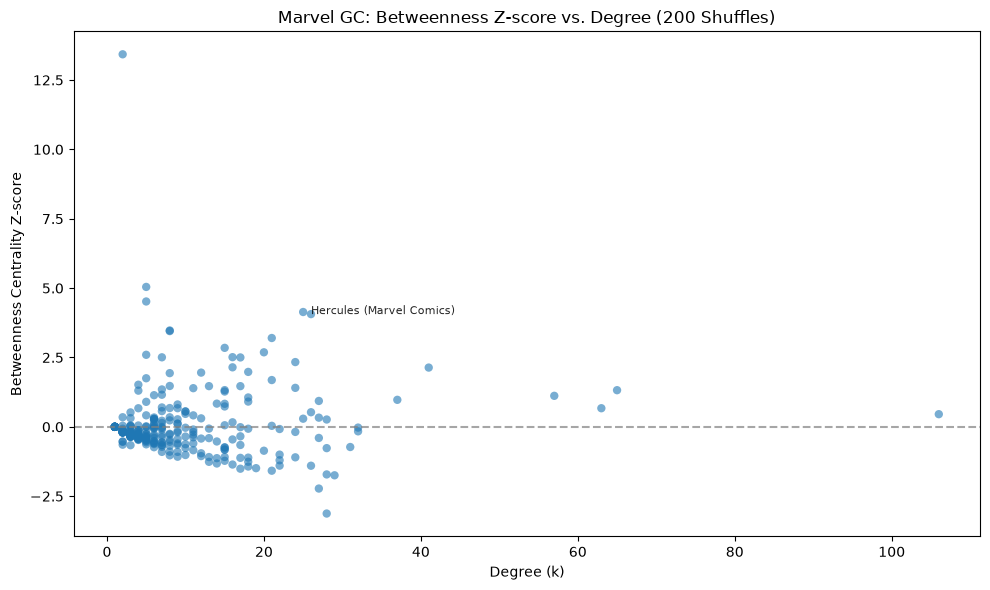

Hercules (Marvel Comics) Betweenness Centrality: 0.037379


In [29]:
null_distributions = np.array(null_distributions)  # Shape: (200, num_nodes)

# Empirical mean and std across the 200 randomized networks
null_means = np.mean(null_distributions, axis=0)
null_stds = np.std(null_distributions, axis=0, ddof=1)
z_scores = np.where(null_stds > 0, (orig_values - null_means) / null_stds, 0.0)

char_z = dict(zip(node_list, z_scores))

# 4. Identify surprises (top / bottom extremes)
sorted_by_z = sorted(char_z.items(), key=lambda x: x[1])
surprises_low = sorted_by_z[:5]    # Over-connected in null, surprisingly low real BC
surprises_high = sorted_by_z[-5:]  # High real BC despite degree (critical brokers)

# 5. Plot z against degree
plt.figure(figsize=(10, 6))
plt.scatter(degrees, z_scores, alpha=0.6, edgecolors="none")
plt.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.xlabel("Degree (k)")
plt.ylabel("Betweenness Centrality Z-score")
plt.title("Marvel GC: Betweenness Z-score vs. Degree (200 Shuffles)")

# Label top surprises
#for name, z in surprises_high + surprises_low:
#    deg = largest_component.degree(name)
#    plt.annotate(name, (deg, z), fontsize=8, alpha=0.85)

# Find and label Hercules as well
hercules_id = nodes[nodes.name == "Hercules (Marvel Comics)"].node_id.values[0]
plt.annotate("Hercules (Marvel Comics)", (largest_component.degree(hercules_id), char_z[hercules_id]), fontsize=8, alpha=0.85)

plt.tight_layout()
plt.show()

# Print Hercules' original betweenness centrality
hercules_bc = original_bc[hercules_id]
print(f"Hercules (Marvel Comics) Betweenness Centrality: {hercules_bc:.6f}")

- Write three sentences for a report that state Hercules's betweenness correctly: the value, the comparison, and what it does and does not mean.
    - We here inspect the betweenness of Hercules from Marvel Comics; his betweenness score in the original components is around 0.037. To see whether this is a high or low value, we compare it with a null model test, where we shuffle links but preserve the degrees of the nodes. In this case, we receive a Z-score of 4.5, so he is far our regarding the deviations, and acts more of a critical broker than we would expect for his amount of degrees. This means that Hercules has a higher impact on information flow (paths) than we would otherwise expect for one with this amount of degrees.

## Mixing Patterns: Do the Important Stick Together?

__Degree Assortativity__: usually we score single nodes, but what about pairs? A networks _mixing pattern_ is about how networks look and mix; most have hubs, where a lot is interconnected. We want _degree assortativity_ $r$ to quantify it. It is the Pearson Correlation beween the degrees at two ends of a link, taken over _all_ the links.   

When $r>0$, the network is __assortative__; hubs links to hubs, likes link to likes etc. When $r < 0$ we say it is __disassortative__, hubs link to low-degree nodes. When $r=0$, degree says nothing about the pairwise linkage.   

Social Networks are usually assortative, whereas biological & technical ones usually are disassortative.

__Visualizing Assortativity__: we can visualize it by on the x-axis serve the (logarithm) of a node's degree, and on the y-axis, we take those nodes' neighbours average degree. If that line is rising, we have $r>0$ otherwise if it is a downwards trending line, we have $r<0$. If it horizontal, it is most likely that $r=0$.

__Assortativity, more generally__: Degree is just one attribute you can choose to focus on. It is possible to use any attribute, and find significance using _shuffling attribute null models_ (not curriculum)

### 3.9) Mixing, compared to what?
1. On paper: what is $r$ for a star (one hub, every other node linked only to it)? Draw a six-node network with $r>0$ and one with $r<0$, and sketch $k_{nn}(k)$ for each. Is a ring assortative, disassortative, or neither?
    - A star would have a very low $r$ assortativity, as the hub would link to edge nodes, and edge nodes to hubs, so a downward trending plot.
    - Example of $r<0$ is the one above, a star network. For $r>0$, make that one a clique, and you have high assortivity.
    - A ring is neither assortative nor disassortative; each links to precisely the same amount as neighbours link to.

In [ ]:
# 2: Compute r for the undirected Marvel giant component and plot k_{nn}​(k) on log axes. 
# Then run the degree-preserving shuffle 200 times and report the z-score of the real r. 
# Write one sentence that states the result correctly.

r_marvel = nx.degree_assortativity_coefficient(largest_component)
r_nulls = np.zeros(200)

for seed in range(200):
    print(".", end="")
    swapped_graph = largest_component.copy()
    nx.double_edge_swap(
        swapped_graph,
        nswap=10 * largest_component.number_of_edges(),
        max_tries=100 * largest_component.number_of_edges(),
        seed=seed,
    )
    r_nulls[seed] = nx.degree_assortativity_coefficient(swapped_graph)

print()

z_score_r = (r_marvel - np.mean(r_nulls)) / np.std(r_nulls, ddof=1)
print(f"2: {z_score_r}")

........................................................................................................................................................................................................
1.522594083919714
-0.10509846258823742


2. So to sum it up, we are around 1 and a half standard deviations out when it comes to the degree assortativity of the Marvel network, not far outside reasons

In [34]:
# 3) Keep the arrows: network_x lets you correlate the out-degree of the source with the in-degree of the target (or in with out). 
# Which of the two is positive on Marvel, and what does it mean about the pages that link out a lot?

r_out_in = nx.degree_pearson_correlation_coefficient(GCC, x="out", y="in")
r_in_out = nx.degree_pearson_correlation_coefficient(GCC, x="in", y="out")

print(f"out-in: {r_out_in}")
print(f"in-out: {r_in_out}")

out-in: -0.014807469395237928
in-out: 0.08892240041236021


3. So for Marvel, there is a positive correlation on the in-degree to out-degree, so it tells us that in the Marvel graph, the in-degree of a node follows the out degree of its neighbours. High in-degree equals a high out-degree of our neighbours.

In [ ]:
# 4) Homophily: pick an attribute you can get for each character from Wikipedia
# (the API notes are in week 1; team membership or first-appearance decade are good)
# Compute the attribute assortativity, and test it against a null 
# that shuffles the attribute labels across nodes rather than the links. 
# Why is that the right null here?

# TO BE DONE

print(nodes.head())

                   node_id                     name wikidata_id  \
0  Abomination_(character)  Abomination (character)      Q60146   
1             Adam_Warlock             Adam Warlock    Q1735229   
2  Agent_X_(Marvel_Comics)  Agent X (Marvel Comics)    Q1054789   
3                     Ajak                     Ajak     Q554230   
4              Alex_Wilder              Alex Wilder    Q3610734   

                                                 url  \
0  https://en.wikipedia.org/wiki/Abomination_(cha...   
1         https://en.wikipedia.org/wiki/Adam_Warlock   
2  https://en.wikipedia.org/wiki/Agent_X_(Marvel_...   
3                 https://en.wikipedia.org/wiki/Ajak   
4          https://en.wikipedia.org/wiki/Alex_Wilder   

                                         description  
0  The Abomination (Emil Blonsky) is a character ...  
1  Adam Warlock is a character appearing in Ameri...  
2  Agent X (Nijo Minamiyori, alias Alex Hayden) i...  
3  Ajak is a fictional character appeari

## Cliques

Each node in the clique is linked to all other, so maximal density; a $k$-clique has $k(k-1)/2$ links, a 3-clique is a triangle. Large cliques are _rare_ because of this.
- __Maximal__: if no node can be added to it (?)
- __Clique Number__: the size of the _largest_ clique.



### 3.10) Cliques By Hand
1. In exercise 3.2's network, list every maximal clique. What is the clique number?
    - Cliques are only of size 2, as no triangles exits or above. Every maximal clique is node pairs formed by edges. The clique number is then $2$.
2. A 6-clique has how many links? What is the smallest degree a node in it can have? Use that to say, without computing anything, which Marvel characters cannot be in the 8-clique.
    - A 6 clique has 15 links [$(6\cdot5)/2 = 15$].
    - The smallest degree a node can have is 5, it _needs_ to connect to the other parts
    - Any with a degree below 7.
3. Explain why a network with clustering coefficient $C=1$ is a set of disconnected cliques, and why $C=0$ means it has no 3-clique at all.
    - The formula for C is $$ C_i = \frac{e_i}{k_i(k_i - 1)/2} = \frac{2e_i}{k_i(k_i - 1)}, $$ and we know that in a clique, we formed an edge to all other nodes in the clique, which coincides exactly with $e_i = k_i(k_i - 1)/2$!  
    If the clustering coefficient for a network is 0, it _must_ neccesarily mean that no nodes has a clustering coefficient above 0; but if we a 3-clique somewhere in the network, then the average would be larger than 0.